# Climate Data Region Masking Workflow — v5

**Objective:** Build a reusable Python workflow that:
1. Filters NARCliM climate model data by Margaret River wine-region boundaries
2. Applies configurable spatial buffers to every region
3. Converts Kelvin → °C at plotting/statistics time
4. Runs kriging interpolation inside every region (sparse→fine grid, gap-fill, centroid interpolation)

## Workflow Overview
| Section | What happens |
|---------|-------------|
| 0 | Setup & paths |
| 1 | Load shapefile & assign official subregion names |
| 2 | Load NARCliM NetCDF grid |
| 3 | Create region masks with configurable buffer |
| 4 | Apply masks & compute regional means |
| 5 | Kriging interpolation (per region) |
| 6 | Save masks |
| 7 | Regional statistics & export |


## 0. Setup and Installation

In [ ]:
# Install required packages (uncomment if needed)
# !pip install geopandas xarray netcdf4 shapely matplotlib pykrige scipy ipywidgets
# !jupyter nbextension enable --py widgetsnbextension   # classic notebook
# !jupyter labextension install @jupyter-widgets/jupyterlab-manager  # JupyterLab

In [1]:
!pip install pykrige

In [2]:

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
from shapely.geometry import Point, Polygon
from shapely.ops import transform
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import zipfile
import warnings
from scipy.interpolate import RBFInterpolator   # always imported as fallback
import ipywidgets as widgets
from IPython.display import display, clear_output

warnings.filterwarnings('ignore')
print("✓ Core libraries imported")

# ── Kriging (pykrige with scipy fallback) ────────────────────────────────────
try:
    from pykrige.ok import OrdinaryKriging
    KRIGING_BACKEND = "pykrige"
    print("✓ pykrige available — using OrdinaryKriging")
except ImportError:
    KRIGING_BACKEND = "scipy_rbf"
    print("⚠ pykrige not found — falling back to scipy RBFInterpolator")


✓ Core libraries imported
✓ pykrige available — using OrdinaryKriging


### Configure Paths

In [3]:
# ── Extract shapefile from zip if needed ─────────────────────────────────────
PROJECT_DIR = Path.cwd()
zip_path    = PROJECT_DIR / "wine_regions_shp.zip"
extract_dir = PROJECT_DIR / "wine_regions_shp"

if zip_path.exists() and not extract_dir.exists():
    print(f"Extracting shapefile from {zip_path.name}...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)
        print(f"  ✓ Extracted: {z.namelist()}")
elif extract_dir.exists():
    print(f"✓ Shapefile directory exists: {extract_dir}")
else:
    print(f"⚠ {zip_path} not found — place the zip in the project directory.")

if extract_dir.exists():
    shp_files = list(extract_dir.glob("*.shp"))
    print(f"  Shapefile(s) found: {[f.name for f in shp_files]}")


✓ Shapefile directory exists: /Users/Prince/Desktop/Project/wine_regions_shp
  Shapefile(s) found: ['Shapefile1.shp']


In [4]:
# ── File paths ───────────────────────────────────────────────────────────────
PROJECT_DIR   = Path.cwd()
SHAPEFILE_PATH = PROJECT_DIR / "wine_regions_shp" / "Shapefile1.shp"

NETCDF_FILES = {
    'tasmax': PROJECT_DIR / "4km_files" /
              "tasmax_SWWA_ACCESS-ESM1-5_historical_r6i1p1f1_R3_v1_day_19510101-19511231.nc",
    'mrsos':  PROJECT_DIR / "4km_files" /
              "mrsos_SWWA_ERA5_historical_r1i1p1f1_R3_v1_3hr_1980010100-1980123121.nc",
}

OUTPUT_DIR = PROJECT_DIR / "region_masks"
OUTPUT_DIR.mkdir(exist_ok=True)

# ── USER-CONFIGURABLE BUFFER (degrees, applied to every region) ───────────────
FIXED_BUFFER_DEG = 0.02   # ~2 km — set to 0 to disable fixed buffer
AUTO_BUFFER_DEG  = 0.01   # incremental buffer for regions with 0 grid cells

# ── KRIGING SETTINGS ─────────────────────────────────────────────────────────
KRIG_FINE_FACTOR = 3      # upscaling factor for fine interpolation grid (3 = 3× denser)
KRIG_VARIOGRAM   = "spherical"   # pykrige variogram model

# ── DEMO REGIONS (all 8 official Margaret River subregions) ──────────────────
DEMO_REGIONS = ["Karridale", "Wallcliffe", "Treeton", "Yallingup",
                "Carbunup", "Wilyabrup", "Region_0", "Region_1"]

print(f"Project directory : {PROJECT_DIR}")
print(f"Fixed buffer      : {FIXED_BUFFER_DEG}°")
print(f"Auto buffer step  : {AUTO_BUFFER_DEG}°")
print(f"Kriging backend   : {KRIGING_BACKEND}")
print(f"Demo regions      : {DEMO_REGIONS}")

print("\nFile verification:")
print(f"  Shapefile : {SHAPEFILE_PATH.exists()} — {SHAPEFILE_PATH.name}")
for k, p in NETCDF_FILES.items():
    print(f"  {k:8s}  : {p.exists()} — {p.name}")


Project directory : /Users/Prince/Desktop/Project
Fixed buffer      : 0.02°
Auto buffer step  : 0.01°
Kriging backend   : pykrige
Demo regions      : ['Karridale', 'Wallcliffe', 'Treeton', 'Yallingup', 'Carbunup', 'Wilyabrup', 'Region_0', 'Region_1']

File verification:
  Shapefile : True — Shapefile1.shp
  tasmax    : True — tasmax_SWWA_ACCESS-ESM1-5_historical_r6i1p1f1_R3_v1_day_19510101-19511231.nc
  mrsos     : True — mrsos_SWWA_ERA5_historical_r1i1p1f1_R3_v1_3hr_1980010100-1980123121.nc


---
## 1. Load Region Shapefile & Assign Official Names

**What happens here:**
- Load the SWWA wine-region shapefile and reproject to WGS84
- Strip Z coordinates (PolygonZ → Polygon)
- Assign the 8 official Margaret River subregion names by index


In [5]:
def load_region_shapefile(shapefile_path):
    """Load shapefile, reproject to EPSG:4326, strip Z coords."""
    print(f"Loading shapefile: {shapefile_path}")
    gdf = gpd.read_file(shapefile_path)

    if gdf.crs.to_epsg() != 4326:
        print(f"  Converting CRS from {gdf.crs} → EPSG:4326")
        gdf = gdf.to_crs("EPSG:4326")

    def drop_z(geom):
        return transform(lambda x, y, z=None: (x, y), geom)
    gdf["geometry"] = gdf["geometry"].apply(drop_z)

    print(f"  ✓ Loaded {len(gdf)} regions | CRS: {gdf.crs}")
    print(f"  ✓ Bounding box: {gdf.total_bounds}")
    return gdf


# ── Load & rename ─────────────────────────────────────────────────────────────
regions_gdf = load_region_shapefile(SHAPEFILE_PATH)

# Hardcoded official subregion names (index → name)
REGION_NAME_MAP = {
    0: "Region_0",    # Tiny coastal polygon (Augusta fringe)
    1: "Region_1",    # Transitional small polygon
    2: "Karridale",
    3: "Wallcliffe",
    4: "Treeton",
    5: "Yallingup",
    6: "Carbunup",
    7: "Wilyabrup",
}
regions_gdf["Region_Name"] = regions_gdf.index.map(REGION_NAME_MAP)
name_col = "Region_Name"

# Guard: ensure every shapefile row has a name in the map
assert len(regions_gdf) <= len(REGION_NAME_MAP), (
    f"Shapefile has {len(regions_gdf)} rows but REGION_NAME_MAP only covers "
    f"{len(REGION_NAME_MAP)} indices. Add missing entries to REGION_NAME_MAP."
)

print("\nRegion names assigned:")
for i, row in regions_gdf.iterrows():
    print(f"  [{i}] {row['Region_Name']}")


Loading shapefile: /Users/Prince/Desktop/Project/wine_regions_shp/Shapefile1.shp
  Converting CRS from EPSG:28350 → EPSG:4326
  ✓ Loaded 8 regions | CRS: EPSG:4326
  ✓ Bounding box: [114.97432976 -34.37664331 115.30133027 -33.53064029]

Region names assigned:
  [0] Region_0
  [1] Region_1
  [2] Karridale
  [3] Wallcliffe
  [4] Treeton
  [5] Yallingup
  [6] Carbunup
  [7] Wilyabrup


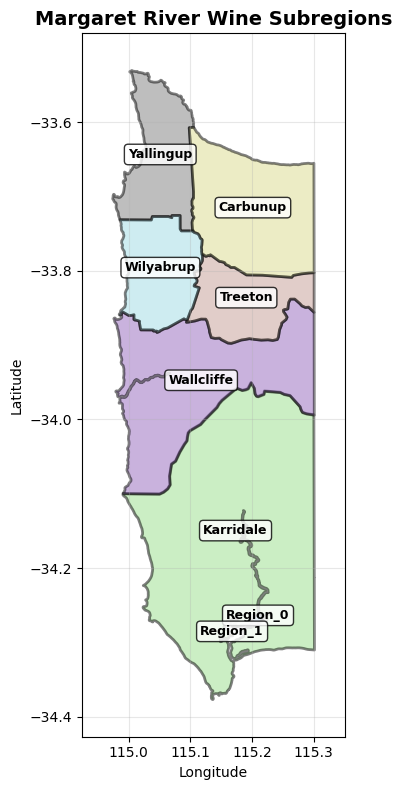

In [6]:
# ── Visualise regions ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
regions_gdf.plot(ax=ax, alpha=0.5, edgecolor="black", cmap="tab20", linewidth=2)

for _, row in regions_gdf.iterrows():
    c = row.geometry.centroid
    ax.text(c.x, c.y, row["Region_Name"], fontsize=9, ha="center", weight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

bounds = regions_gdf.total_bounds
buf = 0.05
ax.set_xlim(bounds[0] - buf, bounds[2] + buf)
ax.set_ylim(bounds[1] - buf, bounds[3] + buf)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Margaret River Wine Subregions", fontsize=14, weight="bold")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## 2. Load Climate Model Grid

Extract 2-D geographic lat/lon from the NARCliM rotated-pole NetCDF files.


In [7]:
def load_climate_grid(netcdf_path):
    """Open a NARCliM NetCDF and return (dataset, lat_2d, lon_2d)."""
    print(f"Loading: {Path(netcdf_path).name}")
    ds    = xr.open_dataset(netcdf_path)
    lat2d = ds["lat"].values
    lon2d = ds["lon"].values
    print(f"  ✓ Grid shape : {lat2d.shape}")
    print(f"  ✓ Lat range  : [{lat2d.min():.2f}, {lat2d.max():.2f}]")
    print(f"  ✓ Lon range  : [{lon2d.min():.2f}, {lon2d.max():.2f}]")
    print(f"  ✓ Time steps : {len(ds.time)}")
    return ds, lat2d, lon2d

ds, lat_grid, lon_grid = load_climate_grid(NETCDF_FILES["tasmax"])

# Verify both grids share the same coordinates
ds2, lat_grid2, lon_grid2 = load_climate_grid(NETCDF_FILES["mrsos"])
grids_match = np.allclose(lat_grid, lat_grid2) and np.allclose(lon_grid, lon_grid2)
print("\n✓ Grids identical:", grids_match)
if not grids_match:
    print("  ⚠ Different grids — will recreate masks per variable")


Loading: tasmax_SWWA_ACCESS-ESM1-5_historical_r6i1p1f1_R3_v1_day_19510101-19511231.nc
  ✓ Grid shape : (279, 364)
  ✓ Lat range  : [-38.24, -26.06]
  ✓ Lon range  : [108.05, 125.16]
  ✓ Time steps : 365
Loading: mrsos_SWWA_ERA5_historical_r1i1p1f1_R3_v1_3hr_1980010100-1980123121.nc
  ✓ Grid shape : (279, 364)
  ✓ Lat range  : [-38.93, -26.22]
  ✓ Lon range  : [107.49, 125.04]
  ✓ Time steps : 2928

✓ Grids identical: False
  ⚠ Different grids — will recreate masks per variable


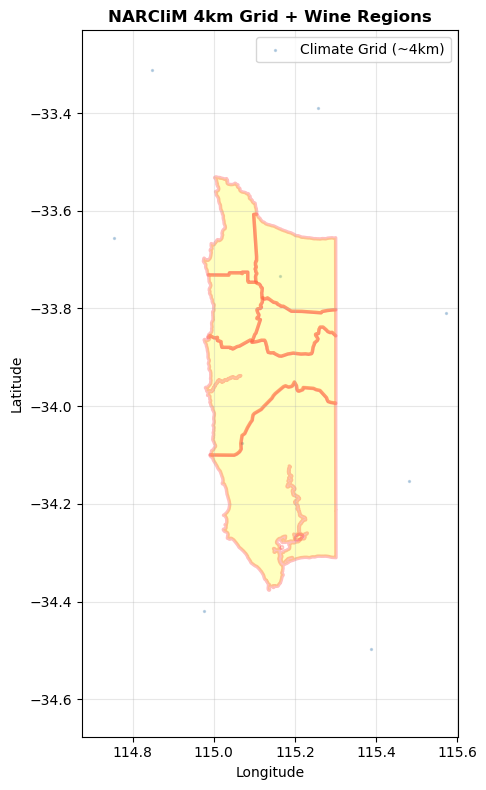

✓ Grid: 101,556 total points (279 rlat × 364 rlon)


In [8]:
# ── Visualise grid + regions (zoomed to wine regions) ────────────────────────
bounds = regions_gdf.total_bounds
buf    = 0.3

fig, ax = plt.subplots(figsize=(9, 8))

s = 10
ax.scatter(lon_grid[::s, ::s], lat_grid[::s, ::s],
           s=2, c="steelblue", alpha=0.3, label="Climate Grid (~4km)")
regions_gdf.plot(ax=ax, alpha=0.25, edgecolor="red",
                 facecolor="yellow", linewidth=2.5, label="Wine Regions")
ax.set_xlim(bounds[0]-buf, bounds[2]+buf)
ax.set_ylim(bounds[1]-buf, bounds[3]+buf)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("NARCliM 4km Grid + Wine Regions", weight="bold")
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f"✓ Grid: {lat_grid.shape[0]*lat_grid.shape[1]:,} total points "
      f"({lat_grid.shape[0]} rlat × {lat_grid.shape[1]} rlon)")


---
## 3. Create Region Masks with Configurable Buffer

Two buffers work together:
- **Fixed buffer** (`FIXED_BUFFER_DEG`) — expands *every* region polygon before masking
- **Auto buffer** (`AUTO_BUFFER_DEG`) — only applied when a region still captures 0 grid cells after the fixed buffer


### 3a. Buffer Widget

Use the sliders below to tune buffer sizes and re-run the masks without restarting the notebook. The global `region_masks` dict is updated in-place.


In [9]:
def create_region_masks(regions_gdf, lat_2d, lon_2d,
                        region_name_col="Region_Name",
                        fixed_buffer_deg=FIXED_BUFFER_DEG,
                        auto_buffer_deg=AUTO_BUFFER_DEG):
    """
    Create boolean masks for each region.

    Parameters
    ----------
    fixed_buffer_deg : float
        Degrees to expand every polygon before masking (0 = disabled).
    auto_buffer_deg : float
        Incremental buffer applied only to regions that still have 0 cells.
    """
    print("Creating region masks...\n")
    print(f"  Fixed buffer : {fixed_buffer_deg}°  |  Auto buffer step : {auto_buffer_deg}°\n")

    # Region name list
    if region_name_col and region_name_col in regions_gdf.columns:
        region_names = [str(n) for n in regions_gdf[region_name_col].tolist()]
    else:
        region_names = [f"Region_{i}" for i in range(len(regions_gdf))]

    # ── Point-in-polygon backend (fastest available) ──────────────────────────
    try:
        from shapely.vectorized import contains as _vec_contains
        def _pip(poly, lons, lats):
            return _vec_contains(poly, lons, lats)
        print("  PIP backend: shapely.vectorized\n")
    except ImportError:
        try:
            from shapely import contains_xy
            def _pip(poly, lons, lats):
                return contains_xy(poly, lons.ravel(), lats.ravel()).reshape(lats.shape)
            print("  PIP backend: shapely.contains_xy\n")
        except ImportError:
            def _pip(poly, lons, lats):
                flat = [Point(x, y) for x, y in zip(lons.ravel(), lats.ravel())]
                return np.array([poly.contains(p) for p in flat]).reshape(lats.shape)
            print("  PIP backend: point-by-point (slow)\n")

    masks = {}
    for region_name, polygon in zip(region_names, regions_gdf.geometry):
        print(f"  {region_name:15s} ... ", end="", flush=True)

        # Apply fixed buffer to every region
        working_poly = polygon.buffer(fixed_buffer_deg) if fixed_buffer_deg > 0 else polygon
        mask_2d = _pip(working_poly, lon_2d, lat_2d)
        n_pts   = int(mask_2d.sum())

        # Auto-buffer if still empty
        if n_pts == 0:
            buf = auto_buffer_deg
            while n_pts == 0 and buf <= 0.1:
                mask_2d = _pip(working_poly.buffer(buf), lon_2d, lat_2d)
                n_pts   = int(mask_2d.sum())
                buf    += auto_buffer_deg
            tag = f"auto-buffered +{buf-auto_buffer_deg:.3f}°" if n_pts > 0 else "EMPTY"
            print(f"{n_pts:4d} cells ({tag})", end="")
        else:
            print(f"{n_pts:4d} cells", end="")

        coverage = 100.0 * n_pts / mask_2d.size
        print(f"  [{coverage:.4f}% of grid]")
        masks[region_name] = mask_2d

    print(f"\n✓ {len(masks)} masks created | "
          f"total cells: {int(sum(m.sum() for m in masks.values())):,}")
    return masks


region_masks = create_region_masks(regions_gdf, lat_grid, lon_grid, name_col)


Creating region masks...

  Fixed buffer : 0.02°  |  Auto buffer step : 0.01°

  PIP backend: shapely.vectorized

  Region_0        ...    1 cells  [0.0010% of grid]
  Region_1        ...    3 cells (auto-buffered +0.010°)  [0.0030% of grid]
  Karridale       ...   77 cells  [0.0758% of grid]
  Wallcliffe      ...   46 cells  [0.0453% of grid]
  Treeton         ...   21 cells  [0.0207% of grid]
  Yallingup       ...   24 cells  [0.0236% of grid]
  Carbunup        ...   33 cells  [0.0325% of grid]
  Wilyabrup       ...   17 cells  [0.0167% of grid]

✓ 8 masks created | total cells: 222


In [10]:
# ── Widget: Buffer Controls ─────────────────────────────────────────────────
# Adjust buffer sizes interactively and re-run mask creation.
# Run this cell first, adjust sliders, then click 'Apply & Re-run Masks'.

w_buf_fixed = widgets.FloatSlider(
    value=FIXED_BUFFER_DEG, min=0.0, max=0.2, step=0.005,
    description="Fixed buffer (°):",
    readout_format=".3f",
    style={"description_width": "140px"},
    layout=widgets.Layout(width="440px"),
)
w_buf_auto = widgets.FloatSlider(
    value=AUTO_BUFFER_DEG, min=0.005, max=0.1, step=0.005,
    description="Auto buffer step (°):",
    readout_format=".3f",
    style={"description_width": "140px"},
    layout=widgets.Layout(width="440px"),
)
w_buf_info = widgets.HTML(value="<i>Adjust sliders, then click the button.</i>")
btn_rerun  = widgets.Button(
    description="▶ Apply & Re-run Masks",
    button_style="primary",
    layout=widgets.Layout(width="220px", height="36px"),
)
out_buf = widgets.Output()

def _rerun_masks(b):
    global region_masks, FIXED_BUFFER_DEG, AUTO_BUFFER_DEG
    FIXED_BUFFER_DEG = w_buf_fixed.value
    AUTO_BUFFER_DEG  = w_buf_auto.value
    with out_buf:
        clear_output(wait=True)
        print(f"Re-running masks with fixed={FIXED_BUFFER_DEG:.3f}°  "
              f"auto={AUTO_BUFFER_DEG:.3f}°\n")
        region_masks = create_region_masks(
            regions_gdf, lat_grid, lon_grid, name_col,
            fixed_buffer_deg=FIXED_BUFFER_DEG,
            auto_buffer_deg=AUTO_BUFFER_DEG,
        )
        # Summary table
        rows = []
        for rname, mask in region_masks.items():
            rows.append({"Region": rname, "Grid cells": int(mask.sum()),
                         "Coverage %": f"{100*mask.sum()/mask.size:.4f}"})
        print(pd.DataFrame(rows).to_string(index=False))
        print("\n✓ region_masks updated — re-run downstream cells to reflect changes.")

btn_rerun.on_click(_rerun_masks)

display(widgets.VBox([
    widgets.HTML("<b>🔧 Buffer Controls</b>"),
    w_buf_fixed,
    w_buf_auto,
    widgets.HTML(
        "<small><b>Fixed buffer</b>: expands every polygon before masking. "
        "<b>Auto buffer</b>: only used when a region still has 0 cells.</small>"
    ),
    btn_rerun,
    out_buf,
]))


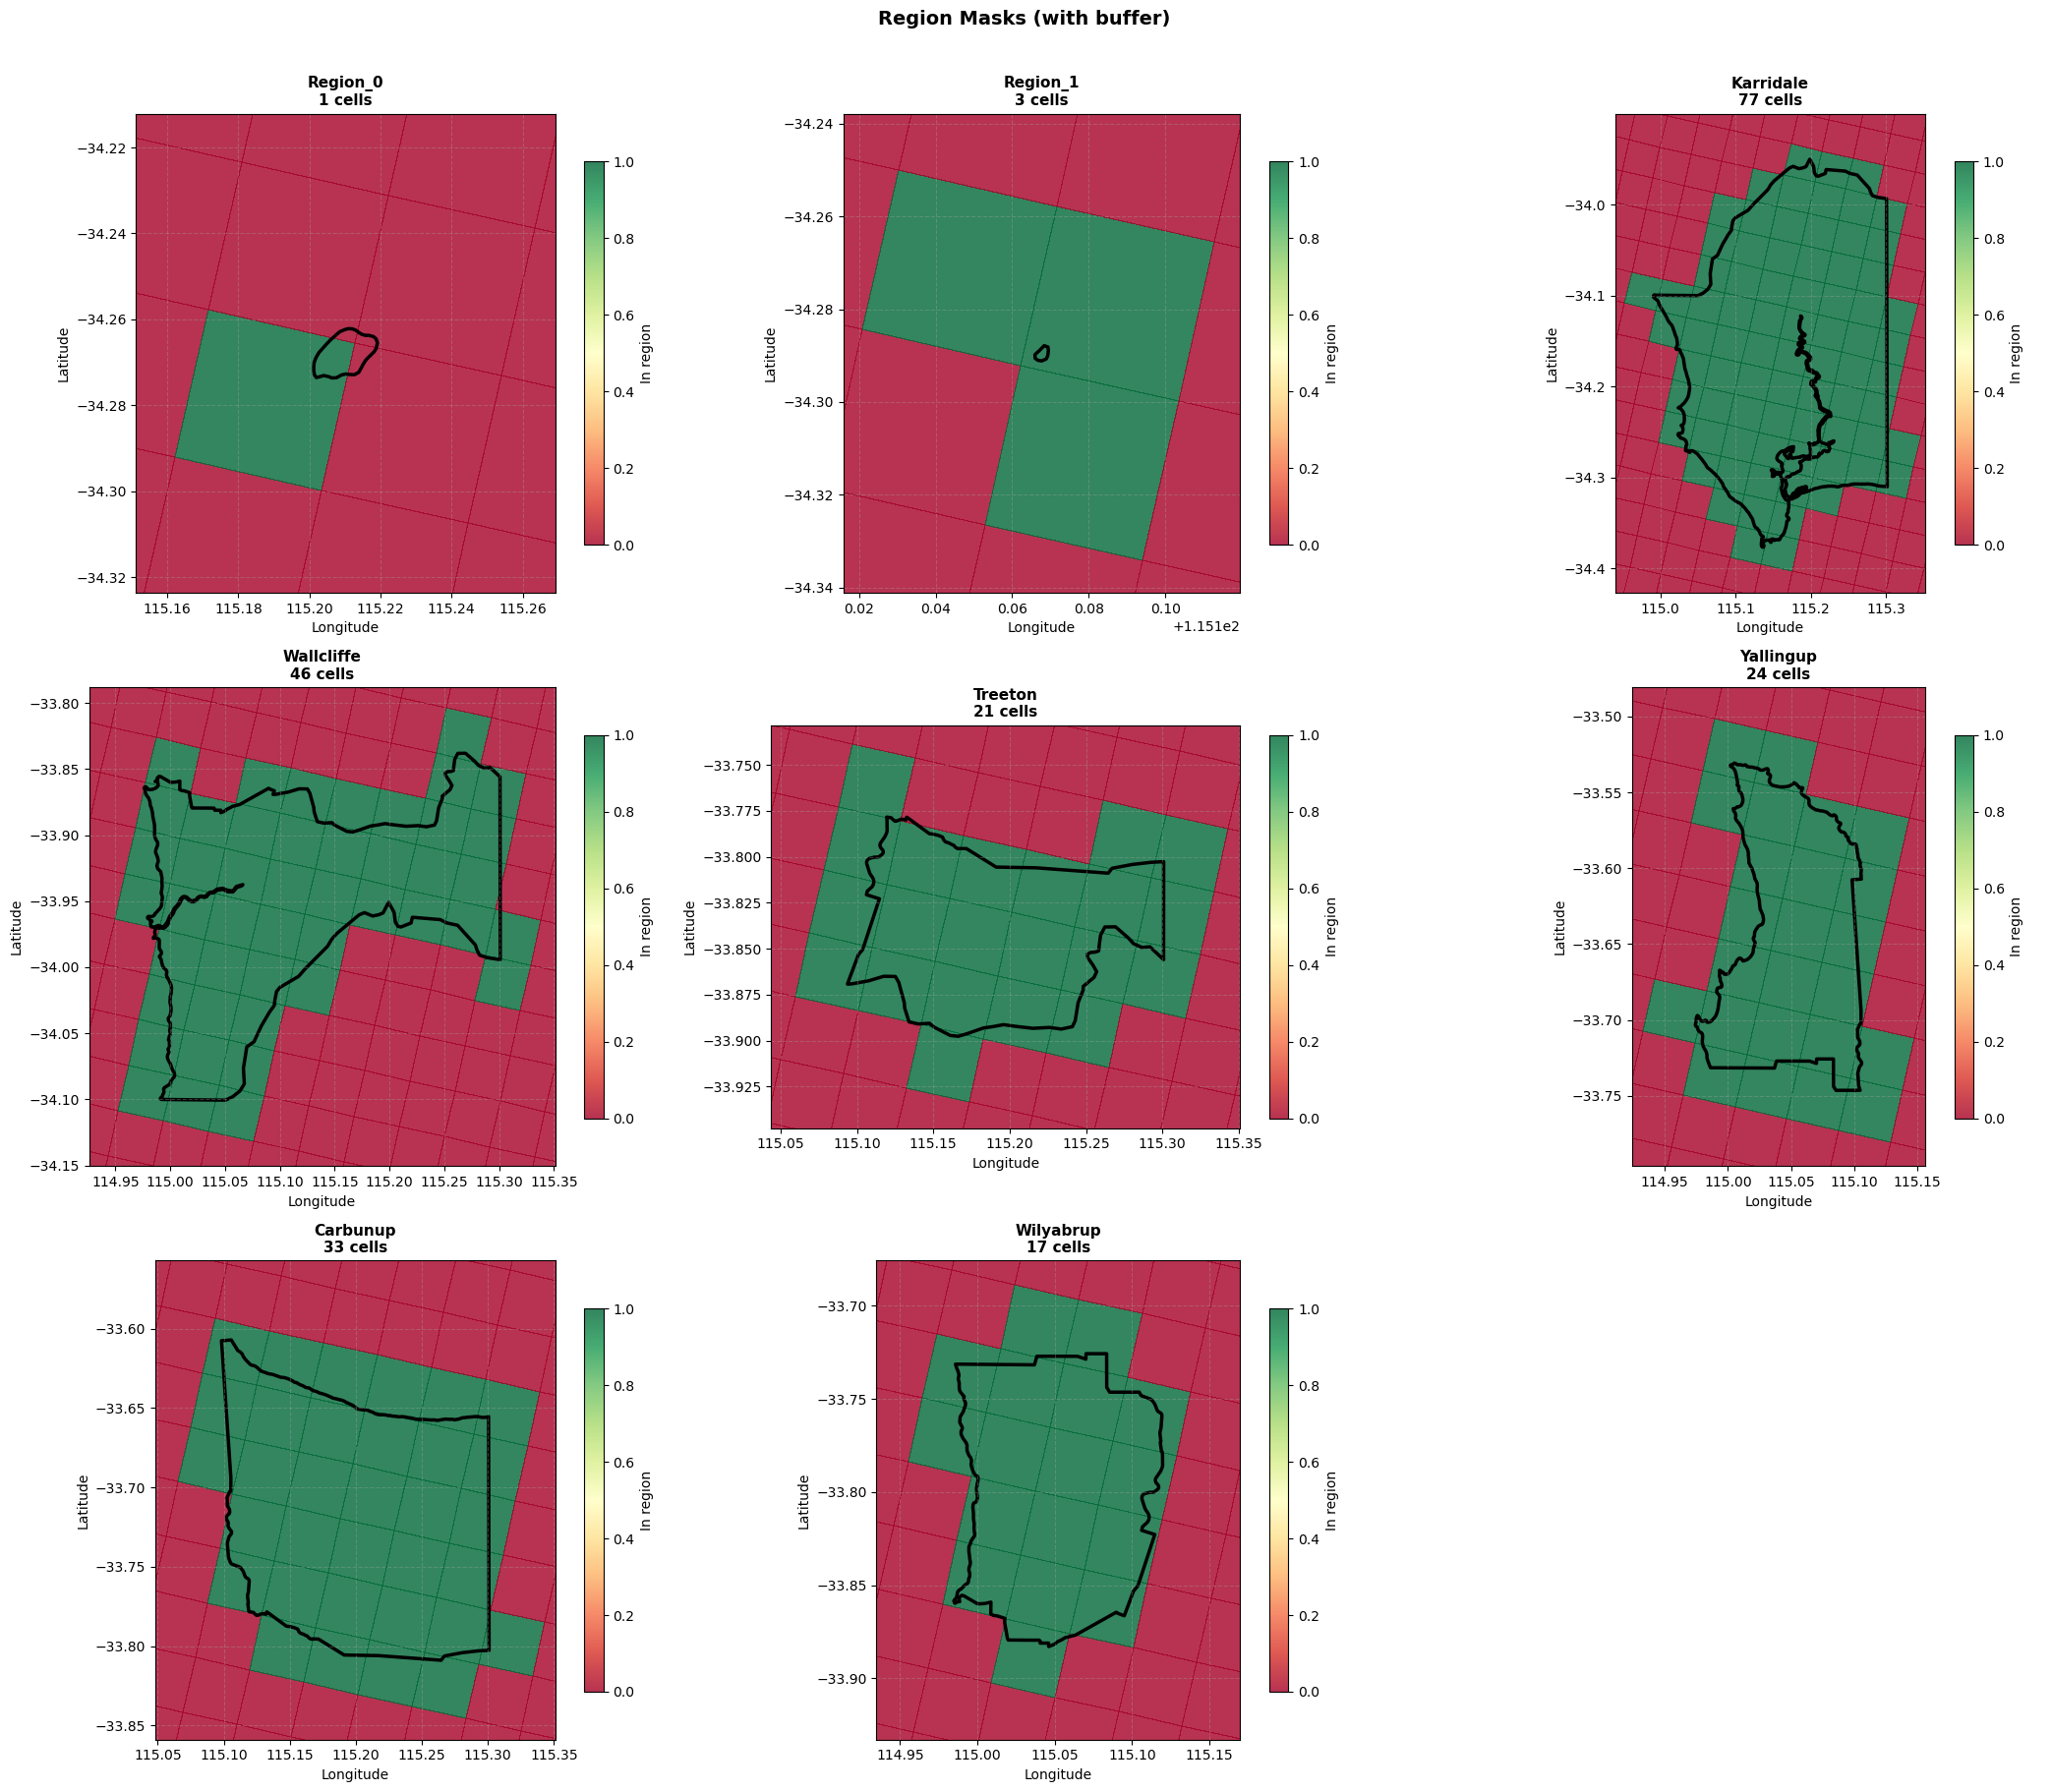

In [11]:
# ── Visualise masks ───────────────────────────────────────────────────────────
valid_regions = {k: v for k, v in region_masks.items() if v.sum() > 0}
empty_regions = [k for k, v in region_masks.items() if v.sum() == 0]

if empty_regions:
    print(f"⚠ No grid cells (even after buffering): {empty_regions}")

n = len(valid_regions)
if n == 0:
    print("⚠ No regions with grid coverage — skipping mask visualisation.")
else:
    n_cols = min(3, n)
    n_rows = (n + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 6*n_rows))
    axes = np.array(axes).flatten() if n > 1 else [axes]

    for pi, (rname, mask) in enumerate(valid_regions.items()):
        ax  = axes[pi]
        row = regions_gdf[regions_gdf[name_col] == rname]
        b   = row.total_bounds
        buf = 0.05

        im = ax.pcolormesh(lon_grid, lat_grid, mask.astype(float),
                           cmap="RdYlGn", alpha=0.8, shading="auto", vmin=0, vmax=1)
        plt.colorbar(im, ax=ax, shrink=0.8, label="In region")
        row.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2.5)
        ax.set_xlim(b[0]-buf, b[2]+buf); ax.set_ylim(b[1]-buf, b[3]+buf)
        ax.set_title(f"{rname}\n{int(mask.sum()):,} cells", weight="bold", fontsize=11)
        ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
        ax.grid(True, alpha=0.3, linestyle="--")

    for pi in range(n, len(axes)):
        axes[pi].axis("off")

    plt.suptitle("Region Masks (with buffer)", fontsize=14, weight="bold", y=1.01)
    plt.tight_layout(); plt.show()


---
## 4. Apply Masks & Compute Regional Means

K→°C conversion happens **at plotting/stats time** — raw data stays in original units.
A helper `to_celsius(da)` is used wherever a plot or stat needs °C.


In [12]:
# ── Helpers ───────────────────────────────────────────────────────────────────
def is_kelvin(da):
    """Return True if the DataArray's units attribute indicates Kelvin."""
    u = da.attrs.get("units", "").strip()
    return u in ("K", "Kelvin", "kelvin")


def to_celsius(da):
    """Convert a DataArray from K to °C if needed; otherwise return as-is."""
    if is_kelvin(da):
        out = da - 273.15
        out.attrs = dict(da.attrs)
        out.attrs["units"] = "°C"
        return out
    return da


def apply_region_mask(dataset, mask, variable_name):
    """Mask a variable: NaN outside the region. No unit conversion here."""
    return dataset[variable_name].where(mask)


def compute_regional_mean(dataset, mask, variable_name):
    """Spatial mean over masked region for every time step (raw units)."""
    spatial_dims = [d for d in dataset[variable_name].dims if d != "time"]
    return apply_region_mask(dataset, mask, variable_name).mean(
        dim=spatial_dims, skipna=True)


# ── Identify climate variable ─────────────────────────────────────────────────
SKIP_VARS = {"crs", "height", "rotated_pole"}
var_name  = next(v for v in ds.data_vars if v not in SKIP_VARS)
units_raw = ds[var_name].attrs.get("units", "unknown")
print(f"Climate variable : {var_name}  |  units : {units_raw}")


Climate variable : tasmax  |  units : K


In [13]:
# ── Run for ALL demo regions ──────────────────────────────────────────────────
demo_results = {}   # {region_name: {"mask", "masked_data", "regional_mean"}}

for demo_region_name in DEMO_REGIONS:
    if demo_region_name not in region_masks:
        print(f"⚠ '{demo_region_name}' not in masks — skipping")
        continue

    mask = region_masks[demo_region_name]
    if mask.sum() == 0:
        print(f"⚠ '{demo_region_name}' has 0 grid cells — skipping")
        continue

    masked_data   = apply_region_mask(ds, mask, var_name)
    regional_mean = compute_regional_mean(ds, mask, var_name)

    demo_results[demo_region_name] = {
        "mask":          mask,
        "masked_data":   masked_data,
        "regional_mean": regional_mean,
    }

    rm_c = to_celsius(regional_mean)
    print(f"{demo_region_name:15s} | {int(mask.sum()):4d} cells | "
          f"mean={float(rm_c.mean().values):.2f} °C  "
          f"[{float(rm_c.min().values):.2f}, {float(rm_c.max().values):.2f}]")

print(f"\n✓ {len(demo_results)} demo regions ready")


Karridale       |   77 cells | mean=20.28 °C  [11.69, 41.85]
Wallcliffe      |   46 cells | mean=20.83 °C  [11.36, 41.40]
Treeton         |   21 cells | mean=21.37 °C  [11.62, 42.12]
Yallingup       |   24 cells | mean=21.26 °C  [12.24, 39.24]
Carbunup        |   33 cells | mean=22.07 °C  [12.46, 41.12]
Wilyabrup       |   17 cells | mean=21.02 °C  [11.27, 40.58]
Region_0        |    1 cells | mean=20.08 °C  [11.88, 43.56]
Region_1        |    3 cells | mean=19.85 °C  [11.65, 43.17]

✓ 8 demo regions ready


In [14]:
# ── Widget: Interactive Time Series ─────────────────────────────────────────
if not demo_results:
    print("⚠ No demo regions with grid coverage — skipping time series widget.")
else:
    _ts_region_list = list(demo_results.keys())

    w_ts_regions = widgets.SelectMultiple(
        options=_ts_region_list,
        value=_ts_region_list,          # all selected by default
        description="Regions:",
        layout=widgets.Layout(width="260px", height="160px"),
        style={"description_width": "70px"},
    )
    w_ts_smooth = widgets.IntSlider(
        value=1, min=1, max=30, step=1,
        description="Rolling avg (days):",
        style={"description_width": "140px"},
        layout=widgets.Layout(width="420px"),
    )
    w_ts_show_raw = widgets.Checkbox(
        value=True, description="Show raw values",
        layout=widgets.Layout(width="200px"),
    )
    out_ts = widgets.Output()

    def _plot_timeseries(regions, smooth, show_raw):
        with out_ts:
            clear_output(wait=True)
            if not regions:
                print("⚠ Select at least one region.")
                return
            fig, ax = plt.subplots(figsize=(15, 5))
            colors = plt.cm.tab10(np.linspace(0, 1, len(regions)))
            for rname, color in zip(regions, colors):
                res  = demo_results[rname]
                rm_c = to_celsius(res["regional_mean"])
                times = pd.to_datetime(rm_c.time.values)
                vals  = rm_c.values
                label = f"{rname} ({int(res['mask'].sum())} cells)"
                if show_raw:
                    ax.plot(times, vals, color=color, alpha=0.3,
                            linewidth=1, linestyle="--")
                if smooth > 1:
                    s = pd.Series(vals).rolling(smooth, center=True,
                                                min_periods=1).mean().values
                    ax.plot(times, s, color=color, linewidth=2, label=label)
                else:
                    ax.plot(times, vals, color=color, linewidth=2,
                            marker="o", markersize=2, label=label)
            ax.set_xlabel("Date", fontsize=12)
            ax.set_ylabel("°C", fontsize=12)
            ax.set_title(f"Regional Mean {var_name} [°C]",
                         fontsize=13, weight="bold")
            ax.legend(loc="best", fontsize=9, framealpha=0.9)
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

    ui_ts = widgets.VBox([
        widgets.HTML("<b>📈 Interactive Time Series</b>"),
        widgets.HBox([
            widgets.VBox([widgets.Label("Select regions:"), w_ts_regions]),
            widgets.VBox([w_ts_smooth, w_ts_show_raw]),
        ]),
        out_ts,
    ])
    display(ui_ts)
    # Trigger initial render
    _ts_out = widgets.interactive_output(
        _plot_timeseries,
        {"regions": w_ts_regions, "smooth": w_ts_smooth, "show_raw": w_ts_show_raw}
    )
    display(_ts_out)
    _plot_timeseries(_ts_region_list, 1, True)


Output()

In [15]:
# ── Widget: Interactive Spatial Map ─────────────────────────────────────────
if not demo_results:
    print("⚠ No demo regions — skipping spatial widget.")
else:
    _sp_region_list = list(demo_results.keys())
    _n_times        = len(ds.time)

    w_sp_region = widgets.Dropdown(
        options=_sp_region_list,
        value=_sp_region_list[0],
        description="Region:",
        style={"description_width": "70px"},
        layout=widgets.Layout(width="260px"),
    )
    w_sp_time = widgets.IntSlider(
        value=0, min=0, max=_n_times - 1, step=1,
        description="Timestep:",
        style={"description_width": "80px"},
        layout=widgets.Layout(width="500px"),
    )
    w_sp_cmap = widgets.Dropdown(
        options=["RdYlBu_r", "RdBu_r", "plasma", "viridis", "coolwarm", "hot_r"],
        value="RdYlBu_r",
        description="Colormap:",
        style={"description_width": "80px"},
        layout=widgets.Layout(width="220px"),
    )
    w_sp_zoom_buf = widgets.FloatSlider(
        value=0.15, min=0.02, max=0.8, step=0.01,
        description="Zoom buffer (°):",
        style={"description_width": "120px"},
        layout=widgets.Layout(width="380px"),
    )

    def _plot_spatial(rname, time_idx, cmap, zoom_buf):
        mask      = demo_results[rname]["mask"]
        timestamp = pd.to_datetime(ds.time[time_idx].values).date()
        masked_c  = to_celsius(
            apply_region_mask(ds, mask, var_name)[time_idx]).values
        row = regions_gdf[regions_gdf[name_col] == rname]
        b   = row.total_bounds

        fig, ax = plt.subplots(figsize=(8, 7))
        im = ax.pcolormesh(lon_grid, lat_grid, masked_c,
                           cmap=cmap, shading="auto")
        plt.colorbar(im, ax=ax, label=f"{var_name} [°C]", fraction=0.046)
        row.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2.5)
        ax.set_xlim(b[0]-zoom_buf, b[2]+zoom_buf)
        ax.set_ylim(b[1]-zoom_buf, b[3]+zoom_buf)
        ax.set_title(f"{rname} — {timestamp}", fontsize=13, weight="bold")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        print(f"  Value range (masked): "
              f"[{np.nanmin(masked_c):.2f}, {np.nanmax(masked_c):.2f}] °C")

    _sp_out = widgets.interactive_output(
        _plot_spatial,
        {"rname": w_sp_region, "time_idx": w_sp_time,
         "cmap": w_sp_cmap, "zoom_buf": w_sp_zoom_buf}
    )

    display(widgets.VBox([
        widgets.HTML("<b>🗺️ Interactive Spatial Map</b>"),
        widgets.HBox([w_sp_region, w_sp_cmap]),
        widgets.HBox([w_sp_time, w_sp_zoom_buf]),
        _sp_out,
    ]))


---
## 5. Kriging Interpolation

Three kriging operations are performed for each demo region at `time_idx = 0`:

| Operation | What it does |
|-----------|-------------|
| **A — Fine grid** | Interpolates the sparse 4km masked points onto a `KRIG_FINE_FACTOR`× denser grid within the region bbox |
| **B — Gap fill** | Fills any NaN cells that remain after masking (e.g. from buffer expansion) by kriging from valid neighbours |
| **C — Centroid** | Fits a kriging surface across all region centroids to produce a smooth region-to-region interpolation |

> **Note:** Kriging quality depends heavily on the number of input points. Very small regions (< 5 cells) will fall back to scipy RBF.


In [16]:
def _krig_or_rbf(x_obs, y_obs, z_obs, x_pred, y_pred, variogram=KRIG_VARIOGRAM):
    """
    Fit ordinary kriging (pykrige) or RBF (scipy) and predict at x_pred, y_pred.
    Returns a flat numpy array of predictions.
    """
    n = len(z_obs)
    if n < 4:
        raise ValueError(f"Need ≥4 points for kriging, got {n}")

    if KRIGING_BACKEND == "pykrige":
        ok = OrdinaryKriging(x_obs, y_obs, z_obs,
                             variogram_model=variogram,
                             verbose=False, enable_plotting=False)
        z_pred, _ = ok.execute("points", x_pred, y_pred)
        return np.asarray(z_pred)
    else:
        rbf    = RBFInterpolator(np.column_stack([x_obs, y_obs]), z_obs, kernel="thin_plate_spline")
        z_pred = rbf(np.column_stack([x_pred, y_pred]))
        return z_pred


def krig_fine_grid(lon_2d, lat_2d, masked_vals, region_bounds,
                   fine_factor=KRIG_FINE_FACTOR, variogram=KRIG_VARIOGRAM):
    """
    Operation A: interpolate sparse masked grid onto a finer regular grid
    inside the region bounding box.
    """
    valid = np.isfinite(masked_vals)
    if valid.sum() < 4:
        return None, None, None, None

    x_obs = lon_2d[valid].ravel()
    y_obs = lat_2d[valid].ravel()
    z_obs = masked_vals[valid].ravel()

    xmin, ymin, xmax, ymax = region_bounds
    nx = int((xmax - xmin) / np.abs(np.diff(lon_2d[0, :]).mean())) * fine_factor
    ny = int((ymax - ymin) / np.abs(np.diff(lat_2d[:, 0]).mean())) * fine_factor
    nx, ny = max(nx, 10), max(ny, 10)

    lon_fine = np.linspace(xmin, xmax, nx)
    lat_fine = np.linspace(ymin, ymax, ny)
    lon_fg, lat_fg = np.meshgrid(lon_fine, lat_fine)

    z_pred = _krig_or_rbf(x_obs, y_obs, z_obs,
                           lon_fg.ravel(), lat_fg.ravel(), variogram)
    return lon_fg, lat_fg, z_pred.reshape(lon_fg.shape), (x_obs, y_obs, z_obs)


def krig_gap_fill(lon_2d, lat_2d, masked_vals, variogram=KRIG_VARIOGRAM):
    """
    Operation B: fill NaN cells inside the masked region using valid neighbours.
    Returns a copy of masked_vals with NaNs filled.
    """
    filled = masked_vals.copy()
    valid  = np.isfinite(masked_vals)
    # nan_m: cells that are NaN (i.e. not finite). Using ~np.isfinite
    # because NaN == NaN is False in IEEE 754, so the previous
    # "~valid & (masked_vals == masked_vals)" was always empty.
    nan_m  = ~np.isfinite(masked_vals)
    if valid.sum() < 4 or nan_m.sum() == 0:
        return filled

    x_obs  = lon_2d[valid].ravel()
    y_obs  = lat_2d[valid].ravel()
    z_obs  = masked_vals[valid].ravel()
    x_pred = lon_2d[nan_m].ravel()
    y_pred = lat_2d[nan_m].ravel()

    try:
        z_fill = _krig_or_rbf(x_obs, y_obs, z_obs, x_pred, y_pred, variogram)
        filled[nan_m] = z_fill
    except Exception as e:
        print(f"    gap-fill skipped: {e}")
    return filled


def krig_centroids(regions_gdf, region_masks, ds, var_name, time_idx=0,
                   lon_2d=None, lat_2d=None, variogram=KRIG_VARIOGRAM,
                   fine_n=80):
    """
    Operation C: fit kriging surface across region centroids, predict on a
    fine grid covering the full region extent.
    """
    centroids_x, centroids_y, z_vals, centroid_names = [], [], [], []

    for _, row in regions_gdf.iterrows():
        rname = row["Region_Name"]
        if rname not in region_masks or region_masks[rname].sum() == 0:
            continue
        mask = region_masks[rname]
        vals = apply_region_mask(ds, mask, var_name)[time_idx].values
        # Convert K → °C for centroid value
        if is_kelvin(ds[var_name]):
            vals = vals - 273.15
        mean_val = float(np.nanmean(vals))
        c = row.geometry.centroid
        centroids_x.append(c.x)
        centroids_y.append(c.y)
        z_vals.append(mean_val)
        centroid_names.append(rname)

    if len(z_vals) < 4:
        print("  ⚠ Fewer than 4 regions with data — centroid kriging skipped")
        return None, None, None, None, None, None, None  # 7 values to match success path

    b   = regions_gdf.total_bounds
    buf = 0.1
    lon_fine = np.linspace(b[0]-buf, b[2]+buf, fine_n)
    lat_fine = np.linspace(b[1]-buf, b[3]+buf, fine_n)
    lon_fg, lat_fg = np.meshgrid(lon_fine, lat_fine)

    z_pred = _krig_or_rbf(np.array(centroids_x), np.array(centroids_y),
                           np.array(z_vals),
                           lon_fg.ravel(), lat_fg.ravel(), variogram)

    # Return names list alongside coords so callers can label correctly
    return (lon_fg, lat_fg, z_pred.reshape(lon_fg.shape),
            np.array(centroids_x), np.array(centroids_y), np.array(z_vals),
            centroid_names)



── Karridale (77 cells) ──────────────────────────────
  A) Fine-grid kriging... done  (36×21 fine grid)


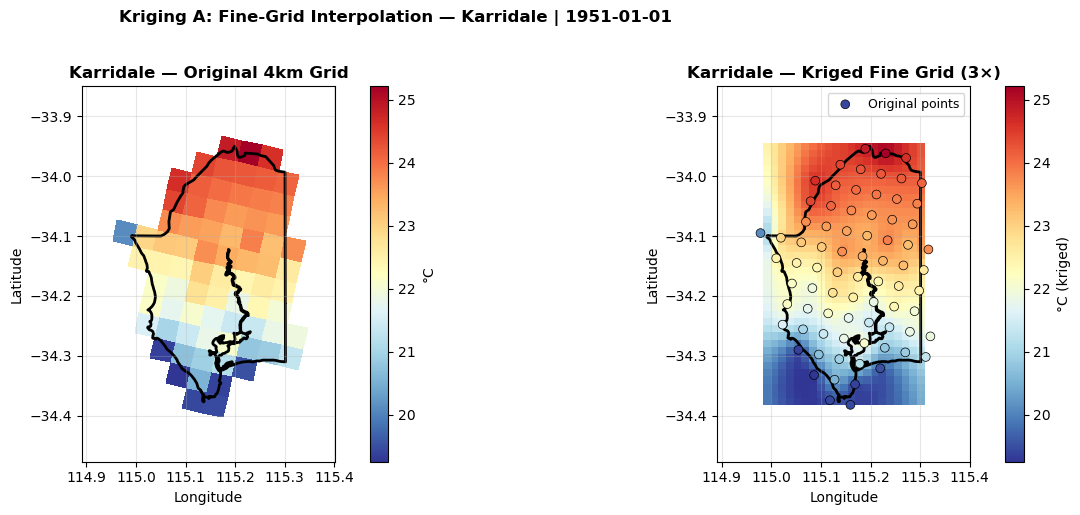

  B) Gap-fill kriging... done  (NaNs inside mask: 0 → 0)

── Wallcliffe (46 cells) ──────────────────────────────
  A) Fine-grid kriging... done  (21×21 fine grid)


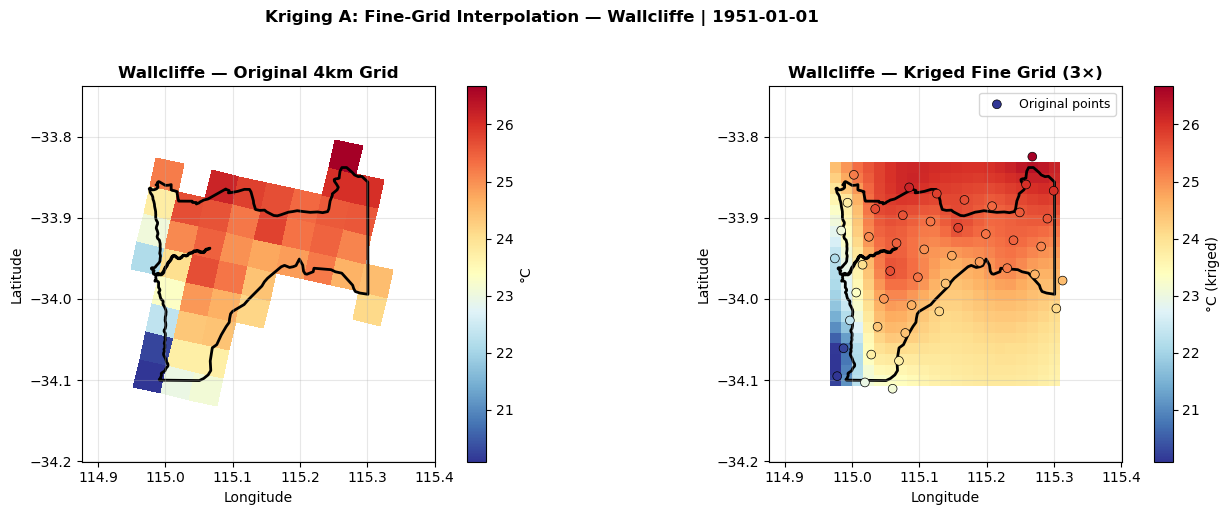

  B) Gap-fill kriging... done  (NaNs inside mask: 0 → 0)

── Treeton (21 cells) ──────────────────────────────
  A) Fine-grid kriging... done  (10×12 fine grid)


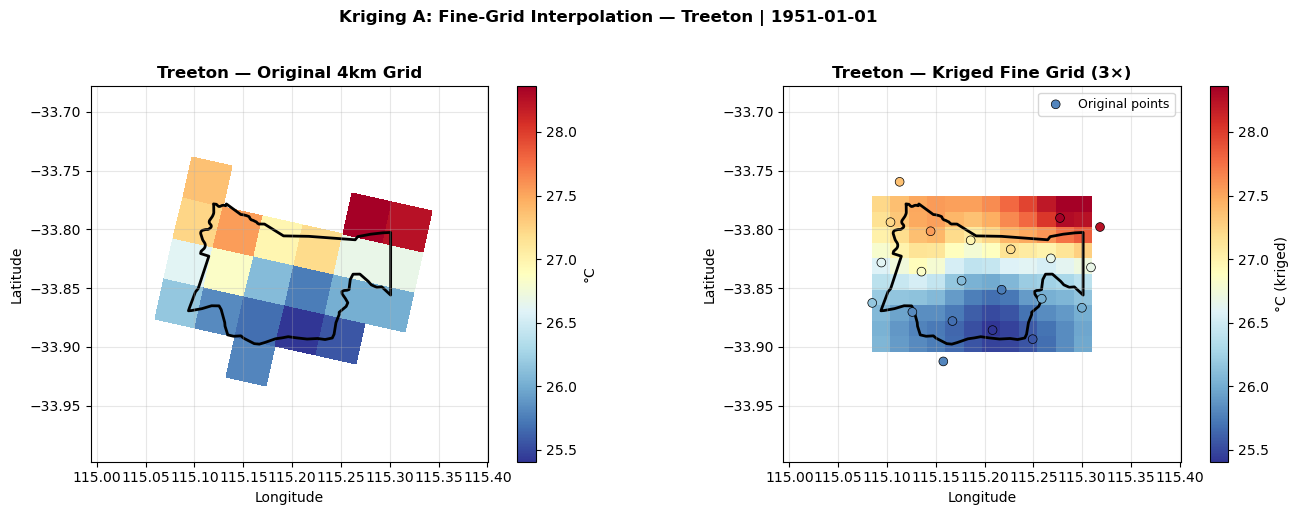

  B) Gap-fill kriging... done  (NaNs inside mask: 0 → 0)

── Yallingup (24 cells) ──────────────────────────────
  A) Fine-grid kriging... done  (18×10 fine grid)


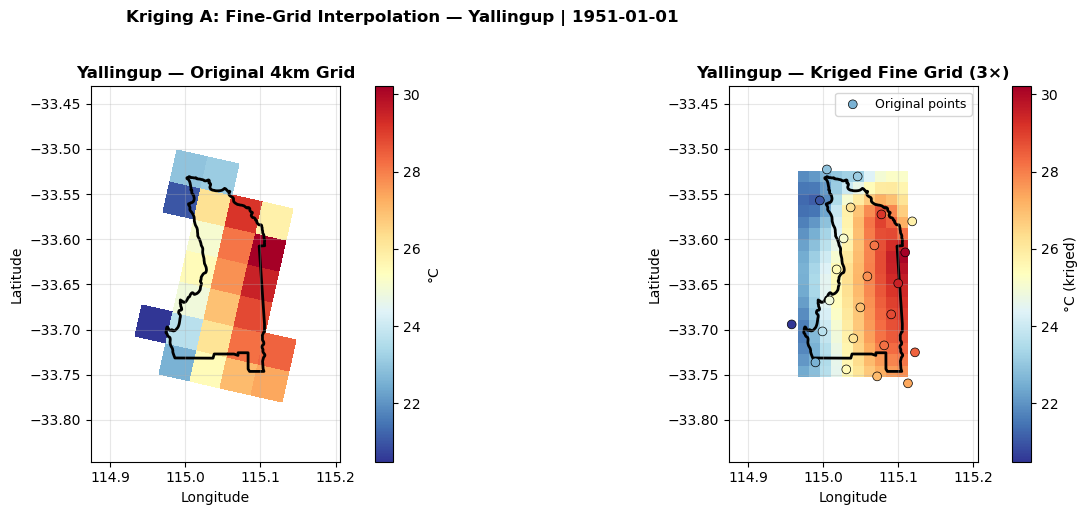

  B) Gap-fill kriging... done  (NaNs inside mask: 0 → 0)

── Carbunup (33 cells) ──────────────────────────────
  A) Fine-grid kriging... done  (15×12 fine grid)


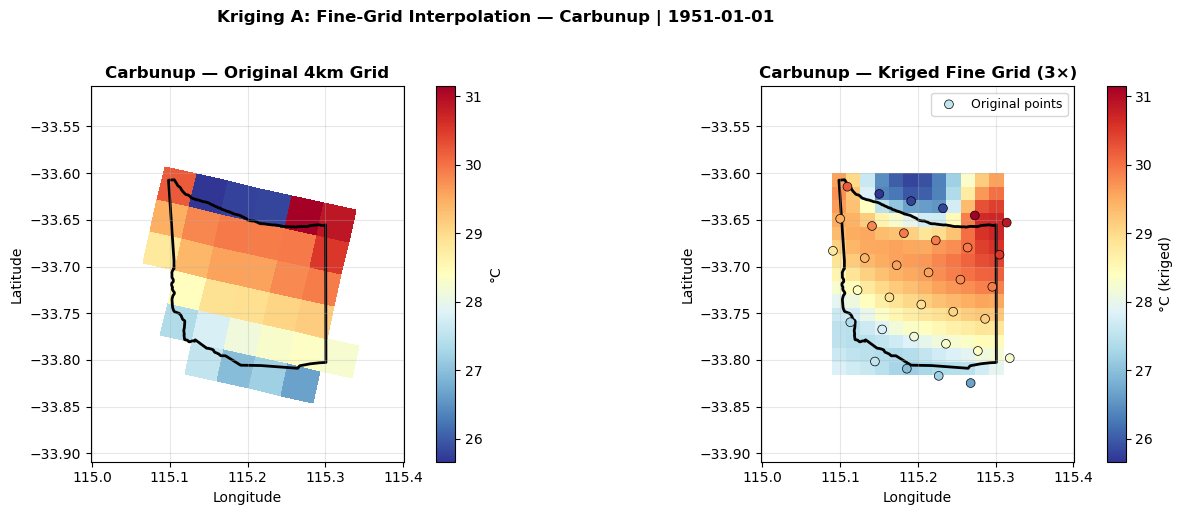

  B) Gap-fill kriging... done  (NaNs inside mask: 0 → 0)

── Wilyabrup (17 cells) ──────────────────────────────
  A) Fine-grid kriging... done  (12×10 fine grid)


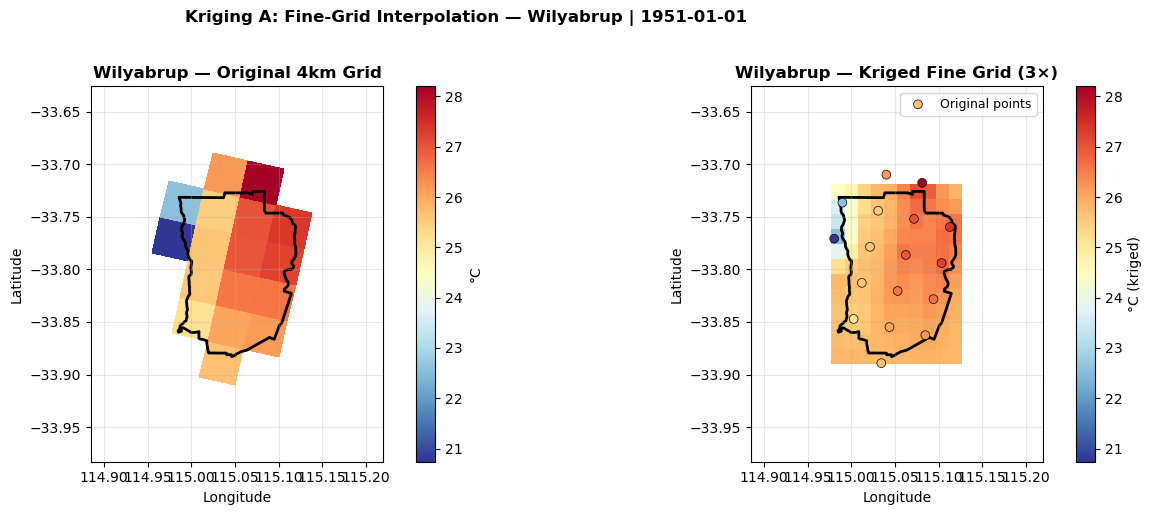

  B) Gap-fill kriging... done  (NaNs inside mask: 0 → 0)

── Region_0 (1 cells) ──────────────────────────────
  A) Fine-grid kriging... skipped (< 4 valid points)
  B) Gap-fill kriging... done  (NaNs inside mask: 0 → 0)

── Region_1 (3 cells) ──────────────────────────────
  A) Fine-grid kriging... skipped (< 4 valid points)
  B) Gap-fill kriging... done  (NaNs inside mask: 0 → 0)

✓ Per-region kriging complete


In [17]:
# ── Run kriging for every demo region ────────────────────────────────────────
time_idx = 0
timestamp = pd.to_datetime(ds.time[time_idx].values).date()

for rname, res in demo_results.items():
    mask        = res["mask"]
    masked_raw  = apply_region_mask(ds, mask, var_name)[time_idx].values
    masked_c    = masked_raw - 273.15 if is_kelvin(ds[var_name]) else masked_raw.copy()

    row    = regions_gdf[regions_gdf[name_col] == rname]
    bounds = row.total_bounds   # [xmin, ymin, xmax, ymax]

    print(f"\n── {rname} ({int(mask.sum())} cells) ──────────────────────────────")

    # ── Operation A: fine-grid interpolation ─────────────────────────────────
    print("  A) Fine-grid kriging...", end=" ")
    lon_fg, lat_fg, z_fine, obs = krig_fine_grid(lon_grid, lat_grid, masked_c, bounds)
    if z_fine is not None:
        print(f"done  ({z_fine.shape[0]}×{z_fine.shape[1]} fine grid)")
        x_obs, y_obs, z_obs = obs

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        ax = axes[0]
        im = ax.pcolormesh(lon_grid, lat_grid, masked_c,
                           cmap="RdYlBu_r", shading="auto")
        plt.colorbar(im, ax=ax, label="°C", fraction=0.046)
        row.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)
        ax.set_xlim(bounds[0]-0.1, bounds[2]+0.1)
        ax.set_ylim(bounds[1]-0.1, bounds[3]+0.1)
        ax.set_title(f"{rname} — Original 4km Grid", weight="bold")
        ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); ax.grid(True, alpha=0.3)

        ax = axes[1]
        vmin, vmax = np.nanmin(z_obs), np.nanmax(z_obs)
        im = ax.pcolormesh(lon_fg, lat_fg, z_fine,
                           cmap="RdYlBu_r", shading="auto", vmin=vmin, vmax=vmax)
        plt.colorbar(im, ax=ax, label="°C (kriged)", fraction=0.046)
        ax.scatter(x_obs, y_obs, c=z_obs, cmap="RdYlBu_r",
                   s=40, edgecolors="k", linewidths=0.5,
                   vmin=vmin, vmax=vmax, label="Original points", zorder=5)
        row.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)
        ax.set_xlim(bounds[0]-0.1, bounds[2]+0.1)
        ax.set_ylim(bounds[1]-0.1, bounds[3]+0.1)
        ax.set_title(f"{rname} — Kriged Fine Grid ({KRIG_FINE_FACTOR}×)", weight="bold")
        ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

        plt.suptitle(f"Kriging A: Fine-Grid Interpolation — {rname} | {timestamp}",
                     fontsize=12, weight="bold", y=1.02)
        plt.tight_layout(); plt.show()
    else:
        print("skipped (< 4 valid points)")

    # ── Operation B: gap fill ────────────────────────────────────────────────
    print("  B) Gap-fill kriging...", end=" ")
    n_nan_before = int(np.sum(mask & ~np.isfinite(masked_c)))
    filled_c     = krig_gap_fill(lon_grid, lat_grid, masked_c)
    n_nan_after  = int(np.sum(mask & ~np.isfinite(filled_c)))
    print(f"done  (NaNs inside mask: {n_nan_before} → {n_nan_after})")

    if n_nan_before > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for ax, data, title in [
            (axes[0], masked_c, "Before gap fill"),
            (axes[1], filled_c, "After gap fill (kriged)"),
        ]:
            im = ax.pcolormesh(lon_grid, lat_grid, data,
                               cmap="RdYlBu_r", shading="auto")
            plt.colorbar(im, ax=ax, label="°C", fraction=0.046)
            row.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)
            ax.set_xlim(bounds[0]-0.1, bounds[2]+0.1)
            ax.set_ylim(bounds[1]-0.1, bounds[3]+0.1)
            ax.set_title(f"{rname} — {title}", weight="bold")
            ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); ax.grid(True, alpha=0.3)
        plt.suptitle(f"Kriging B: Gap Fill — {rname}", fontsize=12, weight="bold", y=1.02)
        plt.tight_layout(); plt.show()

print("\n✓ Per-region kriging complete")


C) Centroid kriging across all regions...


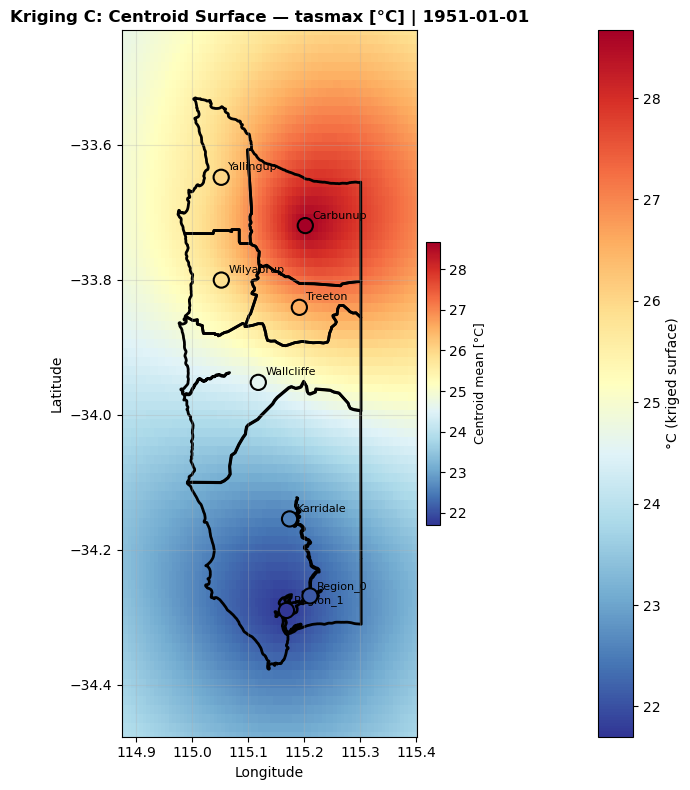

  Surface range: [21.70, 28.67] °C


In [18]:
# ── Operation C: centroid kriging (all regions together) ──────────────────────
print("C) Centroid kriging across all regions...")
result = krig_centroids(regions_gdf, region_masks, ds, var_name,
                        time_idx=time_idx, lon_2d=lon_grid, lat_2d=lat_grid)

if result[0] is not None:
    lon_fg, lat_fg, z_surf, cx, cy, cz, centroid_names = result

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.pcolormesh(lon_fg, lat_fg, z_surf, cmap="RdYlBu_r", shading="auto")
    plt.colorbar(im, ax=ax, label="°C (kriged surface)", fraction=0.046)
    regions_gdf.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)
    sc = ax.scatter(cx, cy, c=cz, cmap="RdYlBu_r", s=120,
                    edgecolors="black", linewidths=1.5, zorder=5,
                    vmin=z_surf.min(), vmax=z_surf.max())
    plt.colorbar(sc, ax=ax, shrink=0.4, pad=0.01,
                 label="Centroid mean °C").set_label("Centroid mean [°C]", fontsize=9)
    # Use centroid_names returned by krig_centroids (guaranteed same order as cx/cy)
    for i, rname in enumerate(centroid_names):
        ax.annotate(rname, (cx[i], cy[i]), fontsize=8,
                    xytext=(5, 5), textcoords="offset points")

    bounds_all = regions_gdf.total_bounds
    buf = 0.1
    ax.set_xlim(bounds_all[0]-buf, bounds_all[2]+buf)
    ax.set_ylim(bounds_all[1]-buf, bounds_all[3]+buf)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title(f"Kriging C: Centroid Surface — {var_name} [°C] | {timestamp}",
                 fontsize=12, weight="bold")
    ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    print(f"  Surface range: [{z_surf.min():.2f}, {z_surf.max():.2f}] °C")


---
## 6. Save Masks for Reuse


In [19]:
def save_masks_netcdf(masks, lat_2d, lon_2d, output_path):
    """Save region masks as NetCDF."""
    data_vars = {}
    for rname, mask in masks.items():
        safe = rname.replace(" ", "_").replace("-", "_").replace(".", "_")
        data_vars[safe] = xr.Variable(
            ["rlat", "rlon"], mask.astype(np.int8),
            {"long_name": f"Mask for {rname}", "flag_values": "0 1",
             "flag_meanings": "outside inside"})

    ds_out = xr.Dataset(
        data_vars,
        coords={
            "rlat": np.arange(lat_2d.shape[0]),
            "rlon": np.arange(lat_2d.shape[1]),
            "lat":  (["rlat", "rlon"], lat_2d),
            "lon":  (["rlat", "rlon"], lon_2d),
        },
        attrs={
            "description":      "Region masks — SWWA wine regions on NARCliM 4km grid",
            "fixed_buffer_deg": str(FIXED_BUFFER_DEG),
            "created":          pd.Timestamp.now().isoformat(),
        })
    ds_out.to_netcdf(output_path)
    print(f"  ✓ NetCDF saved: {output_path.name}  "
          f"({output_path.stat().st_size/1024:.1f} KB)")


def save_masks_numpy(masks, output_dir):
    """Save each mask as .npy."""
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)
    for rname, mask in masks.items():
        safe = rname.replace(" ", "_").replace("-", "_").replace(".", "_")
        np.save(output_dir / f"mask_{safe}.npy", mask)
    print(f"  ✓ {len(masks)} NumPy masks saved to {output_dir.name}/")


print("Saving masks...\n")
save_masks_netcdf(region_masks, lat_grid, lon_grid, OUTPUT_DIR / "region_masks.nc")
save_masks_numpy(region_masks, OUTPUT_DIR / "numpy_masks")
print(f"\n✓ All masks saved to: {OUTPUT_DIR}")


Saving masks...

  ✓ NetCDF saved: region_masks.nc  (2399.5 KB)
  ✓ 8 NumPy masks saved to numpy_masks/

✓ All masks saved to: /Users/Prince/Desktop/Project/region_masks


---
## 7. Regional Statistics & Export

Units converted to °C at compute time.


In [20]:
def compute_regional_statistics(ds, masks, variable_name):
    """Compute stats per region. Converts K→°C before computing."""
    stats = []
    for rname, mask in masks.items():
        n_cells = int(mask.sum())
        if n_cells == 0:
            stats.append({"Region": rname, "Grid_Cells": 0,
                           "Mean": np.nan, "Std": np.nan, "Min": np.nan,
                           "Max": np.nan, "Median": np.nan,
                           "P25": np.nan, "P75": np.nan, "P95": np.nan,
                           "Note": "No grid cells"})
            continue

        mv = to_celsius(apply_region_mask(ds, mask, variable_name))
        vals = mv.values

        stats.append({
            "Region":     rname,
            "Grid_Cells": n_cells,
            "Mean":       float(np.nanmean(vals)),
            "Std":        float(np.nanstd(vals)),
            "Min":        float(np.nanmin(vals)),
            "Max":        float(np.nanmax(vals)),
            "Median":     float(np.nanmedian(vals)),
            "P25":        float(np.nanpercentile(vals, 25)),
            "P75":        float(np.nanpercentile(vals, 75)),
            "P95":        float(np.nanpercentile(vals, 95)),
            "Note":       "°C",
        })
    return pd.DataFrame(stats)


stats_df  = compute_regional_statistics(ds, region_masks, var_name)
stats_file = OUTPUT_DIR / f"{var_name}_regional_statistics.csv"
stats_df.to_csv(stats_file, index=False)

print(f"Regional Statistics for {var_name} [°C]:")
print("=" * 110)
print(stats_df.round(2).to_string(index=False))
print(f"\n✓ Saved to: {stats_file}")


Regional Statistics for tasmax [°C]:
    Region  Grid_Cells  Mean  Std   Min   Max  Median   P25   P75   P95 Note
  Region_0           1 20.08 4.64 11.88 43.56   19.48 16.98 22.31 27.73   °C
  Region_1           3 19.85 4.56 10.44 43.56   19.11 16.88 21.82 27.57   °C
 Karridale          77 20.28 5.12 10.05 44.28   19.25 16.70 22.62 30.67   °C
Wallcliffe          46 20.83 5.62 10.17 42.89   19.67 16.63 23.70 32.34   °C
   Treeton          21 21.37 6.09 10.66 42.94   20.22 16.62 24.70 33.29   °C
 Yallingup          24 21.26 5.50 10.93 41.78   20.07 17.08 24.15 32.22   °C
  Carbunup          33 22.07 6.07 11.12 42.94   20.99 17.34 25.52 33.71   °C
 Wilyabrup          17 21.02 5.70 10.65 41.78   19.78 16.67 24.02 32.68   °C

✓ Saved to: /Users/Prince/Desktop/Project/region_masks/tasmax_regional_statistics.csv


In [21]:
def export_regional_timeseries(ds, masks, variable_name, output_dir):
    """Export per-region daily mean time series to CSV (°C)."""
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)
    exported = 0
    for rname, mask in masks.items():
        if mask.sum() == 0:
            print(f"  Skipping {rname} — no grid cells")
            continue
        rm_c = to_celsius(compute_regional_mean(ds, mask, variable_name))
        df   = rm_c.to_dataframe(name=variable_name).reset_index()
        safe = rname.replace(" ", "_").replace("-", "_").replace(".", "_")
        path = output_dir / f"{variable_name}_{safe}.csv"
        df.to_csv(path, index=False)
        print(f"  Saved: {path.name}")
        exported += 1
    print(f"\n✓ Exported {exported} time series")


export_regional_timeseries(ds, region_masks, var_name, OUTPUT_DIR / "timeseries")


  Saved: tasmax_Region_0.csv
  Saved: tasmax_Region_1.csv
  Saved: tasmax_Karridale.csv
  Saved: tasmax_Wallcliffe.csv
  Saved: tasmax_Treeton.csv
  Saved: tasmax_Yallingup.csv
  Saved: tasmax_Carbunup.csv
  Saved: tasmax_Wilyabrup.csv

✓ Exported 8 time series


In [22]:
# ── MRSOS dataset with same masks ────────────────────────────────────────────
print("Using MRSOS dataset with existing masks\n")
ds_mrsos, lat_m, lon_m = load_climate_grid(NETCDF_FILES["mrsos"])

if not (np.allclose(lat_grid, lat_m) and np.allclose(lon_grid, lon_m)):
    print("Different grids — recreating masks for mrsos grid...")
    region_masks_mrsos = create_region_masks(regions_gdf, lat_m, lon_m, name_col)
else:
    region_masks_mrsos = region_masks
    print("Same grid — reusing masks")

mrsos_var = next(v for v in ds_mrsos.data_vars if v not in SKIP_VARS)
print(f"\nVariable: {mrsos_var}  units: {ds_mrsos[mrsos_var].attrs.get('units','?')}")

for rname, mask in region_masks_mrsos.items():
    if mask.sum() == 0:
        continue
    rm = compute_regional_mean(ds_mrsos, mask, mrsos_var)
    print(f"  {rname:15s}: mean={float(rm.mean().values):.4f} "
          f"{ds_mrsos[mrsos_var].attrs.get('units','')}")


Using MRSOS dataset with existing masks

Loading: mrsos_SWWA_ERA5_historical_r1i1p1f1_R3_v1_3hr_1980010100-1980123121.nc
  ✓ Grid shape : (279, 364)
  ✓ Lat range  : [-38.93, -26.22]
  ✓ Lon range  : [107.49, 125.04]
  ✓ Time steps : 2928
Different grids — recreating masks for mrsos grid...
Creating region masks...

  Fixed buffer : 0.02°  |  Auto buffer step : 0.01°

  PIP backend: shapely.vectorized

  Region_0        ...    2 cells  [0.0020% of grid]
  Region_1        ...    1 cells  [0.0010% of grid]
  Karridale       ...   76 cells  [0.0748% of grid]
  Wallcliffe      ...   47 cells  [0.0463% of grid]
  Treeton         ...   17 cells  [0.0167% of grid]
  Yallingup       ...   24 cells  [0.0236% of grid]
  Carbunup        ...   33 cells  [0.0325% of grid]
  Wilyabrup       ...   21 cells  [0.0207% of grid]

✓ 8 masks created | total cells: 221

Variable: mrsos  units: kg m-2
  Region_0       : mean=262.9849 kg m-2
  Region_1       : mean=236.3550 kg m-2
  Karridale      : mean=252.

---
## Summary

### ✓ What this notebook does

1. **Loads the SWWA wine-region shapefile** — reprojects EPSG:28350 → WGS84, strips Z coords
2. **Assigns official subregion names** — hardcoded `REGION_NAME_MAP` (index → name)
3. **Loads NARCliM 4km grid** — extracts 2-D geographic lat/lon from rotated-pole NetCDF
4. **Creates masks with dual buffer** — fixed buffer on every region + auto-buffer for empty ones
5. **Applies masks & computes means** — raw units preserved; K→°C conversion at plot/stats time
6. **Kriging** for all 8 demo regions:
   - **A** Fine-grid interpolation (sparse 4km → `KRIG_FINE_FACTOR`× denser)
   - **B** Gap-fill of NaN cells inside masked region
   - **C** Centroid surface across all regions
7. **Saves** masks as NetCDF + NumPy; statistics & time series as CSV

### Next Steps
- Tune `FIXED_BUFFER_DEG` and `KRIG_FINE_FACTOR` for your resolution needs
- Swap `KRIG_VARIOGRAM` model (`spherical`, `exponential`, `gaussian`) and compare
- Apply the same workflow to additional variables via `NETCDF_FILES`
